In [9]:
from matplotlib import pyplot as plt
import statsmodels.api as sm
import pandas as pd
import seaborn as sns
import yfinance as yf
import numpy as np
import pandas_datareader as web

sns.set_style("dark")

In [21]:
# Descargar datos mensuales de los últimos 
sp500_raw = yf.download("^GSPC", start="2016-01-01", end="2026-12-31", progress=True)["Close"]
vix_raw = yf.download("^VIX", start="2016-01-01", end="2026-12-31", progress=True)["Close"]

# VIX desde FRED (alternativa más robusta para datos macro)
# vix_raw = web.DataReader("VIXCLS", "fred", "2016,01,01", "2026-12-31")

# Resampleo mensual (último valor del mes)
sp500_monthly = sp500_raw.resample("ME").last()
vix_monthly = vix_raw.resample("ME").last()

# Merge
df = pd.concat([sp500_monthly, vix_monthly], axis=1)
df.columns = ["SP500", "VIX"]
df = df.dropna()

print(df.head(10))
print(f"\nObservaciones: {len(df)}")



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  SP500        VIX
2016-01-31  1940.239990  20.200001
2016-02-29  1932.229980  20.549999
2016-03-31  2059.739990  13.950000
2016-04-30  2065.300049  15.700000
2016-05-31  2096.949951  14.190000
2016-06-30  2098.860107  15.630000
2016-07-31  2173.600098  11.870000
2016-08-31  2170.949951  13.420000
2016-09-30  2168.270020  13.290000
2016-10-31  2126.149902  17.059999

Observaciones: 126


In [27]:
# Paso 2: Calcular retornos y cambios
# Retorno mensual del S&P 500 (variable independiente X)
df["r_SP500"] = df["SP500"].pct_change()

# Cambio mensual del VIX (variable dependiente Y)
df["d_VIX"] = df["VIX"].pct_change()

# Eliminar NaN generados por pct_change
df = df.dropna()

print(df[["r_SP500", "d_VIX"]].describe())

          r_SP500       d_VIX
count  124.000000  124.000000
mean     0.011957    0.025929
std      0.043897    0.249408
min     -0.125119   -0.458969
25%     -0.008975   -0.130068
50%      0.017904   -0.007045
75%      0.035835    0.135469
max      0.126844    1.128981


<function matplotlib.pyplot.show(close=None, block=None)>

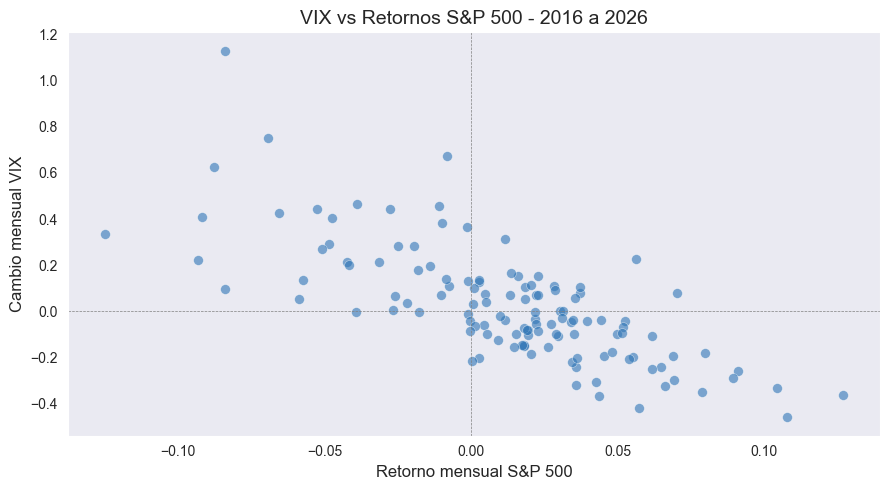

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df["r_SP500"], df["d_VIX"],
           alpha=0.6, color="#2E75B6", s=50,
           edgecolors="white", linewidth=0.4)

ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

ax.set_xlabel("Retorno mensual S&P 500", fontsize=12)
ax.set_ylabel("Cambio mensual VIX", fontsize=12)
ax.set_title("VIX vs Retornos S&P 500 - 2016 a 2026", fontsize=14)

plt.tight_layout()
plt.show

In [ ]:
# Interpretación:
# El gráfico presenta una relación negativa entre el S&P 500 y el VIX. A medida que mayor es el retorno, baja el VIX.

In [44]:
# Paso 3 - 4: Modelo de Regresión Simple

import statsmodels.api as sm

# Variable independiente X -> retorno S&P 500
# Variable dependiente Y -> cambio VIX
X = sm.add_constant(df["r_SP500"]) # agrega la columna del intercepto
y = df["d_VIX"]

# Estimar modelo OLS (MCO)
modelo_simple = sm.OLS(y, X).fit()

# Resultados
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_VIX   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     151.3
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           4.14e-23
Time:                        18:37:11   Log-Likelihood:                 46.752
No. Observations:                 124   AIC:                            -89.50
Df Residuals:                     122   BIC:                            -83.86
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0765      0.016      4.909      0.0

In [ ]:
# Modelo estimado: d_VIX = 0.0765 + (-4.2274) x r_SP500
# R² -> El modelo explica el 55.4% de la variabilidad en los cambios del VIX.
# F-Statistic ->  El modelo es significativo.
# Prob(F) -> Tendencia a cero; se rechaza H₀ de que β₁ = 0

# Coeficientes
# Constante (0.0765, p < 0.001) -> Cuando el retorno del S&P 500 es 0%, el VIX sube en promedio un 7.65% mensual. Hay una presión alcista natural sobre la volatilidad.
# r_SP500 (-4.2274, p < 0.001) -> Por cada 1% de retorno adicional en el S&P, el VIX cae en promedio un 4.23%. Relación inversa.

# Diagnóstico de los residuos
# Sin autocorrelación según prueba de Durbin-Watson (2.377)
# Los residuos NO son normales según Jarque-Bera (p≈0)
# Asimetría positiva (cola derecha) según Skewness (0.968)
# Distribución leptocúrtica (colas pesadas) según prueba de Kurtosis (5.312)
# Sin problemas de multicolinealidad

# La relación negativa entre retornos del S&P 500 y cambios del VIX está bien capturada (R² = 55%), pero los residuos no son normales (colas pesadas, asimetría). Esto sugiere que en períodos de estrés extremo, hay desvíos grandes no capturados por el modelo lineal.

In [47]:
# Paso 5: Establecer una prueba de hipótesis para el parámetro de interés

# Hipótesis nula H0: β = 0; El S&P 500 no explica el VIX
# Hipótesis alternativa H1: β = 1; El S&P 500 sí explica el VIX

# p-valor < 0.05  →  Rechazamos H₀  →  β es significativo
# p-valor > 0.05  →  No rechazamos H₀  →  β no es significativo

# Extraer coeficientes del modelo
beta  = modelo_simple.params['r_SP500']   # el β estimado
error = modelo_simple.bse['r_SP500']      # error estándar de β
tstat = modelo_simple.tvalues['r_SP500']  # estadístico t
pval  = modelo_simple.pvalues['r_SP500']  # p-valor

print(f"β estimado      : {beta:.4f}")
print(f"Error estándar  : {error:.4f}")
print(f"Estadístico t   : {tstat:.4f}")
print(f"p-valor         : {pval:.4f}")


β estimado      : -4.2274
Error estándar  : 0.3437
Estadístico t   : -12.3001
p-valor         : 0.0000


In [53]:
print("─" * 45)
print("PRUEBA DE HIPÓTESIS SOBRE β")
print("─" * 45)
print(f"H₀: β = 0  →  S&P 500 no explica el VIX")
print(f"H₁: β ≠ 0  →  S&P 500 sí explica el VIX")
print("─" * 45)
print(f"β estimado      : {beta:.4f}")
print(f"Estadístico t   : {tstat:.4f}")
print(f"p-valor         : {pval:.4f}")
print("─" * 45)

if pval < 0.05:
    print(f"✓ p-valor ({pval:.4f}) < 0.05")
    print("→ Rechazamos H₀")
    print("→ β es estadísticamente significativo")
    print("→ El S&P 500 SÍ explica el cambio en el VIX")
else:
    print(f"✗ p-valor ({pval:.4f}) > 0.05")
    print("→ No rechazamos H₀")
    print("→ β no es estadísticamente significativo")
print("-" * 45)

─────────────────────────────────────────────
PRUEBA DE HIPÓTESIS SOBRE β
─────────────────────────────────────────────
H₀: β = 0  →  S&P 500 no explica el VIX
H₁: β ≠ 0  →  S&P 500 sí explica el VIX
─────────────────────────────────────────────
β estimado      : -4.2274
Estadístico t   : -12.3001
p-valor         : 0.0000
─────────────────────────────────────────────
✓ p-valor (0.0000) < 0.05
→ Rechazamos H₀
→ β es estadísticamente significativo
→ El S&P 500 SÍ explica el cambio en el VIX
---------------------------------------------


In [59]:
# Ajustar el modelo de regresión y mostrar visualmente
# Rango de valores para dibujar la recta
x_range = np.linspace(df["r_SP500"].min(),
                      df["r_SP500"].max(), 200)

# Aplicamos la ecuación: y = α + β * x
y_pred = (modelo_simple.params["const"] + modelo_simple.params["r_SP500"] * x_range)